<a href="https://colab.research.google.com/github/Joelmagranes/Final-DataScience-/blob/main/finaldatascience2_joel_magranes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Factores del rendimiento académico: un enfoque predictivo con Machine Learning

#MOTIVACION


---


El rendimiento académico de los estudiantes es uno de los indicadores más importantes dentro de cualquier sistema educativo, y comprender qué factores lo determinan tiene implicancias directas en la calidad de la enseñanza y en el diseño de políticas públicas. Sin embargo, la relación entre variables como el entorno familiar, el acceso a recursos, los hábitos de estudio y el desempeño final en un examen rara vez se analiza de forma integrada y cuantitativa.
Este trabajo busca abordar esa brecha: a partir de un dataset con 6.607 estudiantes y 19 variables que capturan tanto factores individuales (horas de estudio, horas de sueño, motivación) como contextuales (nivel de ingresos familiar, tipo de escuela, involucramiento parental), se construyen modelos de Machine Learning capaces de predecir el puntaje final obtenido en el examen.
La pregunta central que guía el análisis es: ¿en qué medida los factores socioeconómicos, pedagógicos y conductuales de un estudiante permiten anticipar su rendimiento académico?

#AUDIENCIA OBJETIVO


---

| Audiencia | ¿Cómo se beneficia? |
|----------|----------------------|
| Docentes y tutores | Identificar tempranamente estudiantes en riesgo y focalizar el apoyo pedagógico |
| Directivos escolares | Tomar decisiones informadas sobre recursos (tutorías, acceso a internet, etc.) |
| Familias | Comprender qué hábitos y entornos favorecen el aprendizaje |
| Investigadores en educación | Disponer de un análisis cuantitativo de factores académicos para complementar estudios cualitativos |


#DESCRIPCION DE VARIABLES

---


| Variable                     | Descripción                                                                 | Tipo de dato |
|------------------------------|------------------------------------------------------------------------------|--------------|
| Horas Estudiadas             | Cantidad de horas dedicadas al estudio por semana                           | int64        |
| Asistencia                   | Nivel o porcentaje de asistencia del estudiante                              | int64        |
| Involvimiento Parental       | Grado de participación de los padres en el proceso educativo                 | object       |
| Acceso a Recursos            | Indica si el estudiante cuenta con recursos educativos                       | object       |
| Actividades Extraescolares   | Participación en actividades fuera del horario escolar                       | object       |
| Horas de sueño               | Promedio de horas de sueño diarias                                           | int64        |
| Puntuaciones anteriores      | Puntaje obtenido en evaluaciones previas                                     | int64        |
| Nivel de motivación          | Grado de motivación del estudiante                                           | object       |
| Acceso a Internet            | Indica si el estudiante tiene acceso a internet                              | object       |
| Sesiones de tutoría          | Número de sesiones de apoyo académico recibidas                              | int64        |
| Ingresos familiares          | Nivel de ingresos del hogar                                                  | object       |
| Calidad del profesor         | Evaluación de la calidad docente                                             | object       |
| Tipo de escuela              | Tipo de institución educativa (pública/privada)                              | object       |
| Influencia de los vecinos    | Percepción del entorno barrial                                               | object       |
| Actividad física             | Frecuencia o cantidad de actividad física semanal                            | int64        |
| Capacidades de aprendizaje   | Indica si el estudiante presenta capacidades o dificultades específicas       | object       |
| Nivel educativo de los padres| Máximo nivel educativo alcanzado por los padres                              | object       |
| Distancia de casa            | Distancia entre el hogar y la escuela                                        | object       |
| Género                       | Género del estudiante                                                        | object       |
| Exam Score                   | Puntaje final del examen (variable objetivo)                                 | int64        |


#PREGUNTAS Y PROBLEMAS A RESOLVER

---
PROBLEMA PRINCIPAL:

El objetivo central de este trabajo es abordar un problema de regresión, cuyo propósito es predecir el puntaje final obtenido por un estudiante en un examen a partir de un conjunto de variables individuales, familiares y escolares.

La variable objetivo (target) es:
exam score


---

HIPOTESIS

¿En qué medida los factores socioeconómicos, pedagógicos y conductuales permiten anticipar el rendimiento académico de un estudiante?

---
Objetivos específicos:


* Construir y comparar diferentes modelos de Machine Learning orientados a la predicción del puntaje final.

* Evaluar el desempeño de los modelos mediante validación cruzada.

* Optimizar hiperparámetros para mejorar la capacidad predictiva.

* Identificar los factores que más contribuyen al rendimiento académico, con el fin de generar información útil para docentes, directivos y organismos educativos.


---

JUSTIFICACION:

Comprender qué factores influyen en el rendimiento académico permite:

* Detectar estudiantes en riesgo.

* Orientar intervenciones pedagógicas.

* Optimizar recursos institucionales.

* Generar evidencia para políticas educativas.

Si bien el dataset es sintético, el ejercicio metodológico permite explorar cómo técnicas de Machine Learning pueden aplicarse al análisis educativo y qué tipo de variables suelen tener mayor peso en la predicción.

#Importacion del Dataset y librerias


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import sys
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

url = "https://raw.githubusercontent.com/Joelmagranes/Final-Datascience2/main/StudentPerformanceFactors%20(1).csv"

df = pd.read_csv(url)


# Analisis Exploratorio (EDA)


In [ ]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.shape

(6607, 20)

Traduccion de las columnas

In [ ]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [ ]:
traduccion= { "Hours_Studied": "Horas_Estudiadas",
             "Attendance": "Asistencia",
             "Parental_Involvement": "Involvimiento_Parental",
             "Access_to_Resources": "Acceso_a_Recursos",
             "Extracurricular_Activities": "Actividades_Extraescolares",
             "Sleep_Hours": "Horas_de_sueño",
             "Previous_Scores": "Puntuaciones_anteriores",
             "Motivation_Level": "Nivel_de_motivacion",

             "Internet_Access": "Acceso_a_Internet",

             "Tutoring_Sessions": "Sesiones_de_tutoría",
             "Family_Income": "Ingresos_familiares",
             "Teacher_Quality" : "Calidad_del_profesor",
             "School_Type": "Tipo_de_escuela",
             "Peer_Influence": "Influencia_de_los_vecinos",
             "Physical_Activity" : "Actividad_fisica",

            "Learning_Disabilities": "capacidades_de_aprendizaje",
       "Parental_Education_Level": "Nivel_educativo_de_los_padres",
       "Gender": "Genero",
        "Distance_from_Home" : "Distancia_de_casa",
       "Exam_Score": "Exam_Score",

}

In [ ]:
df.rename(columns=traduccion, inplace=True)
df.columns=df.columns.str.replace("_", " ")
df.head()

,Horas Estudiadas,Asistencia,Involvimiento Parental,Acceso a Recursos,Actividades Extraescolares,Horas de sueño,Puntuaciones anteriores,Nivel de motivacion,Acceso a Internet,Sesiones de tutoría,Ingresos familiares,Calidad del profesor,Tipo de escuela,Influencia de los vecinos,Actividad fisica,capacidades de aprendizaje,Nivel educativo de los padres,Distancia de casa,Genero,Exam Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
df.sample(7)

,Horas Estudiadas,Asistencia,Involvimiento Parental,Acceso a Recursos,Actividades Extraescolares,Horas de sueño,Puntuaciones anteriores,Nivel de motivacion,Acceso a Internet,Sesiones de tutoría,Ingresos familiares,Calidad del profesor,Tipo de escuela,Influencia de los vecinos,Actividad fisica,capacidades de aprendizaje,Nivel educativo de los padres,Distancia de casa,Genero,Exam Score
271,11,76,Low,Medium,Yes,5,92,Medium,Yes,4,Medium,Low,Public,Negative,2,No,Postgraduate,Near,Male,65
6178,30,91,High,Low,Yes,6,69,Medium,Yes,2,Medium,High,Public,Negative,4,No,High School,Moderate,Female,72
6202,34,93,High,Medium,Yes,6,93,High,Yes,2,Low,High,Public,Neutral,4,No,High School,Near,Male,77
5372,13,62,Low,Medium,Yes,9,87,Medium,Yes,1,Low,Medium,Public,Negative,1,No,College,Moderate,Male,60
1725,27,67,High,Low,No,8,89,Low,Yes,1,Low,Low,Public,Positive,3,No,Postgraduate,Near,Female,66
4788,7,72,Medium,Medium,Yes,4,94,Medium,Yes,4,Medium,Medium,Private,Positive,4,No,Postgraduate,Near,Male,66
1517,24,60,Low,Low,No,7,66,Medium,Yes,1,Medium,High,Public,Neutral,4,No,College,Near,Female,62


In [ ]:
df.tail()

,Horas Estudiadas,Asistencia,Involvimiento Parental,Acceso a Recursos,Actividades Extraescolares,Horas de sueño,Puntuaciones anteriores,Nivel de motivacion,Acceso a Internet,Sesiones de tutoría,Ingresos familiares,Calidad del profesor,Tipo de escuela,Influencia de los vecinos,Actividad fisica,capacidades de aprendizaje,Nivel educativo de los padres,Distancia de casa,Genero,Exam Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [ ]:
resumen = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
resumen

,Tipo,Nulos,% Nulos,Únicos
Horas Estudiadas,int64,0,0.00,41
Asistencia,int64,0,0.00,41
Involvimiento Parental,object,0,0.00,3
Acceso a Recursos,object,0,0.00,3
Actividades Extraescolares,object,0,0.00,2
Horas de sueño,int64,0,0.00,7
Puntuaciones anteriores,int64,0,0.00,51
Nivel de motivacion,object,0,0.00,3
Acceso a Internet,object,0,0.00,2
Sesiones de tutoría,int64,0,0.00,9


In [ ]:
df.duplicated().sum().sum()

np.int64(0)

In [ ]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Horas Estudiadas,6607.0,19.98,5.99,1.0,16.0,20.0,24.0,44.0
Asistencia,6607.0,79.98,11.55,60.0,70.0,80.0,90.0,100.0
Horas de sueño,6607.0,7.03,1.47,4.0,6.0,7.0,8.0,10.0
Puntuaciones anteriores,6607.0,75.07,14.40,50.0,63.0,75.0,88.0,100.0
Sesiones de tutoría,6607.0,1.49,1.23,0.0,1.0,1.0,2.0,8.0
Actividad fisica,6607.0,2.97,1.03,0.0,2.0,3.0,4.0,6.0
Exam Score,6607.0,67.24,3.89,55.0,65.0,67.0,69.0,101.0


Antes de modelar, es fundamental entender cómo se distribuye la variable objetivo (Exam Score). Este gráfico permite ver si los puntajes se concentran en ciertos rangos, si hay sesgos importantes, outliers evidentes y si la forma de la distribución se aproxima o no a una normal, algo clave para elegir y evaluar modelos de regresión.

## Variable Objetivo

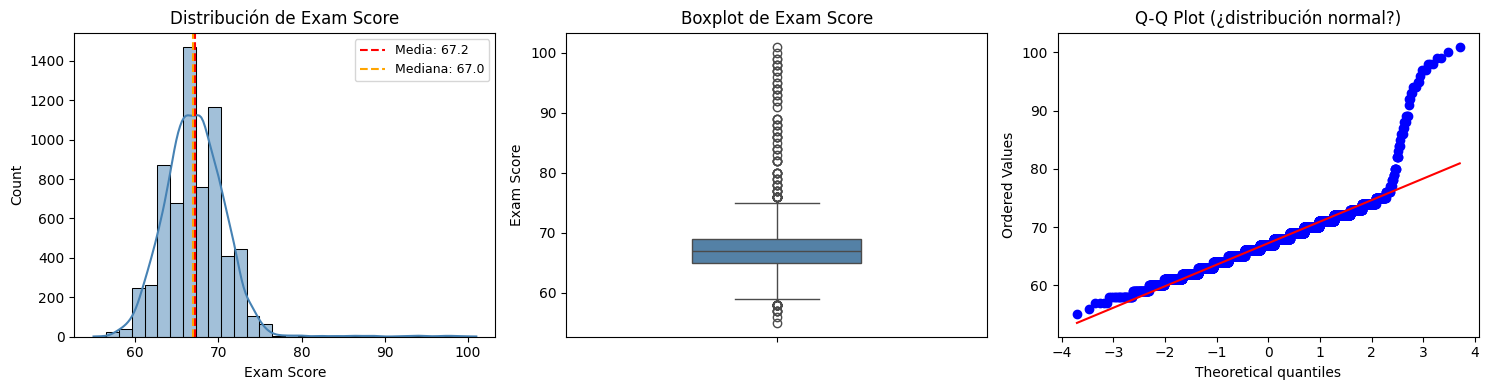

Skewness:  1.645  (>0 = cola a la derecha)
Kurtosis:  10.575
Rango:     55 – 101


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma con KDE
sns.histplot(df['Exam Score'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de Exam Score')
axes[0].axvline(df['Exam Score'].mean(), color='red', linestyle='--', label=f'Media: {df["Exam Score"].mean():.1f}')
axes[0].axvline(df['Exam Score'].median(), color='orange', linestyle='--', label=f'Mediana: {df["Exam Score"].median():.1f}')
axes[0].legend(fontsize=9)

# Boxplot
sns.boxplot(y=df['Exam Score'], ax=axes[1], color='steelblue', width=0.4)
axes[1].set_title('Boxplot de Exam Score')

# QQ-plot (normalidad)
stats.probplot(df['Exam Score'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (¿distribución normal?)')

plt.tight_layout()
plt.show()

# Métricas de forma
print(f'Skewness:  {df["Exam Score"].skew():.3f}  (>0 = cola a la derecha)')
print(f'Kurtosis:  {df["Exam Score"].kurtosis():.3f}')
print(f'Rango:     {df["Exam Score"].min()} – {df["Exam Score"].max()}')

La distribución de Exam Score presenta una skewness positiva, lo que indica una cola algo más larga hacia la derecha. La kurtosis es alta (10.575), lo que sugiere una distribución más picuda y con colas más pesadas que una normal. Aun así, visualmente la distribución no presenta outliers severos y la media y la mediana son muy similares, lo que indica estabilidad general. El Q-Q plot confirma que, aunque no es perfectamente normal, la desviación no afecta la aplicabilidad de modelos de regresión.
se detecto un valor que aparece como outliers, pero se deduce que es un error de tipeo, ya que en un examen no podes sacar un "101". se opto por no eliminar la fila, y considerarlo un 100

In [ ]:
df.loc[df['Exam Score'] > 100, 'Exam Score'] = 100


## Visualizacion de Nulos

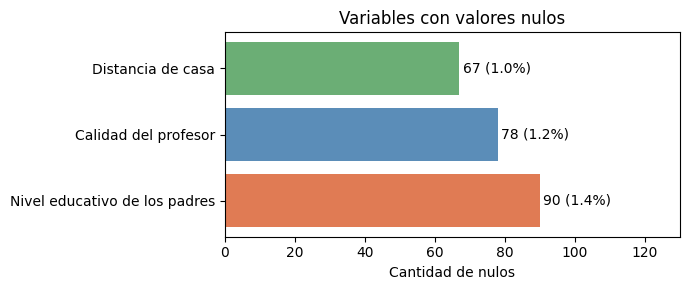


¿Los nulos afectan el score?
  Nivel educativo de los padres: media con nulo=67.06 | sin nulo=67.24
  Calidad del profesor: media con nulo=66.64 | sin nulo=67.24
  Distancia de casa: media con nulo=66.43 | sin nulo=67.24


In [ ]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(nulos.index, nulos.values, color=['#E07B54', '#5B8DB8', '#6BAE75'])
for bar, val in zip(bars, nulos.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=10)
ax.set_title('Variables con valores nulos')
ax.set_xlabel('Cantidad de nulos')
ax.set_xlim(0, nulos.max() + 40)
plt.tight_layout()
plt.show()

# ¿Los nulos son aleatorios? Comparar Exam Score entre nulos y no nulos
print('\n¿Los nulos afectan el score?')
for col in nulos.index:
    grupo_nulo = df[df[col].isnull()]['Exam Score'].mean()
    grupo_ok   = df[df[col].notna()]['Exam Score'].mean()
    print(f'  {col}: media con nulo={grupo_nulo:.2f} | sin nulo={grupo_ok:.2f}')

El gráfico muestra que solo tres variables presentan valores faltantes: Distancia de casa, Calidad del profesor y Nivel educativo de los padres, todas con menos del 1.5% de nulos. La baja magnitud de estos valores indica que la imputación es sencilla y no compromete la integridad del dataset. Además, al comparar el puntaje promedio entre filas con nulos y sin nulos, se observa que las diferencias son mínimas, lo que sugiere que los nulos son aleatorios y no afectan significativamente el rendimiento académico.

##Variables numéricas vs Exam Score

Scatterplots de variables numéricas vs Exam Score

---

se incorpora una línea de tendencia y el coeficiente de correlación ayuda a identificar patrones lineales, fuerza de relación y posibles comportamientos no lineales

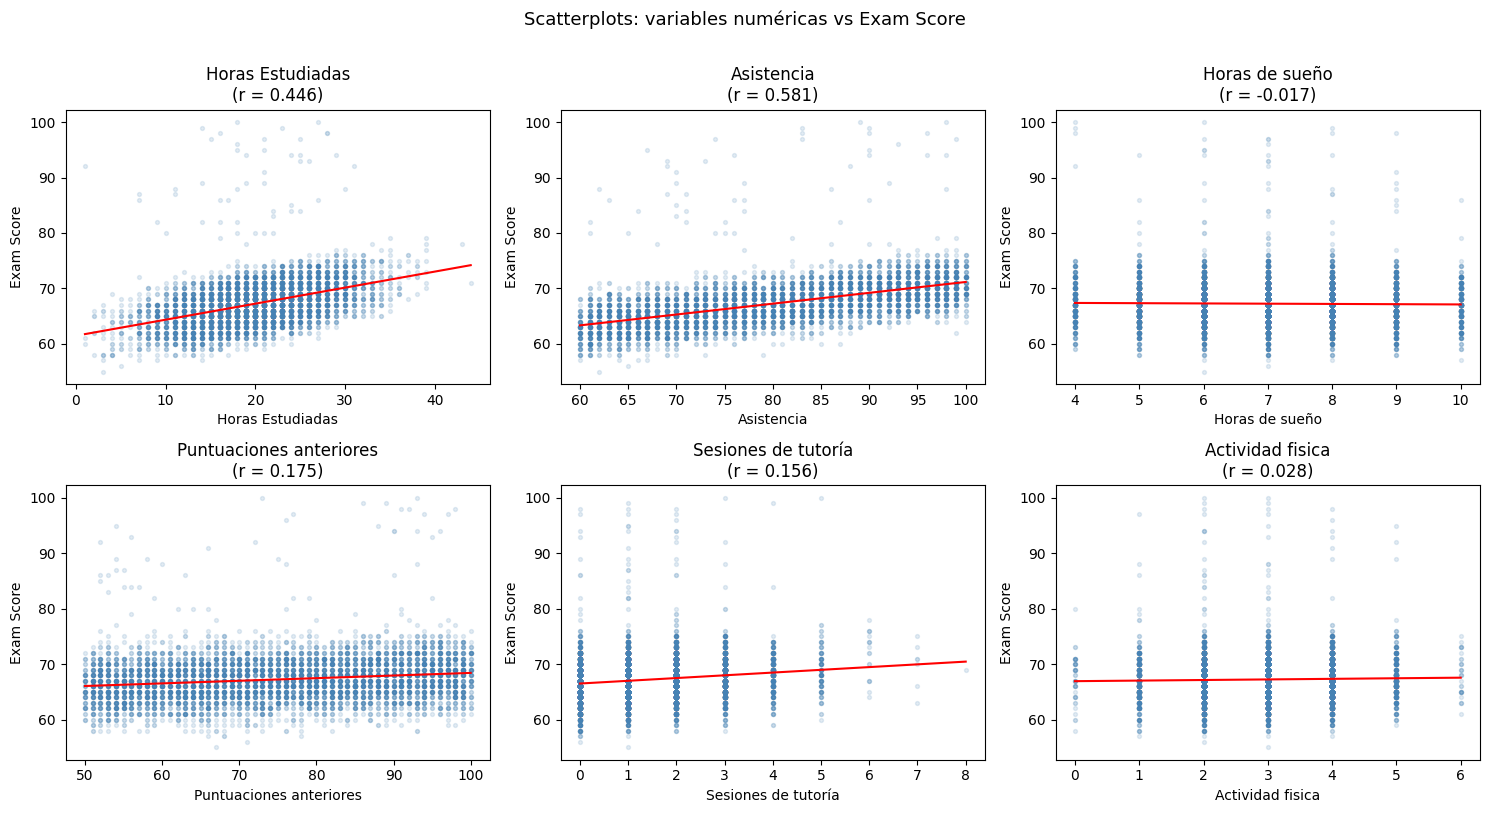

In [ ]:
num_cols = [
    "Horas Estudiadas",
    "Asistencia",
    "Horas de sueño",
    "Puntuaciones anteriores",
    "Sesiones de tutoría",
    "Actividad fisica"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(df[col], df['Exam Score'],
                    alpha=0.15, s=8, color='steelblue')

    # Línea de tendencia
    m, b = np.polyfit(df[col].dropna(), df.loc[df[col].notna(), 'Exam Score'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m*x_line + b, color='red', linewidth=1.5)

    corr = df[[col, 'Exam Score']].corr().iloc[0, 1]
    axes[i].set_title(f'{col}\n(r = {corr:.3f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Exam Score')

plt.suptitle('Scatterplots: variables numéricas vs Exam Score', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


Los gráficos muestran que Asistencia y Horas Estudiadas presentan correlaciones moderadas y positivas con el puntaje final, lo que indica que a mayor dedicación y asistencia, mejor rendimiento. Puntuaciones anteriores muestra una correlación débil pero positiva. En contraste, Horas de sueño, Actividad física y Sesiones de tutoría presentan correlaciones casi nulas, lo que sugiere que su impacto directo en el puntaje es limitado. La dispersión observada confirma que el rendimiento académico depende de múltiples factores combinados.

##Matriz de correlación

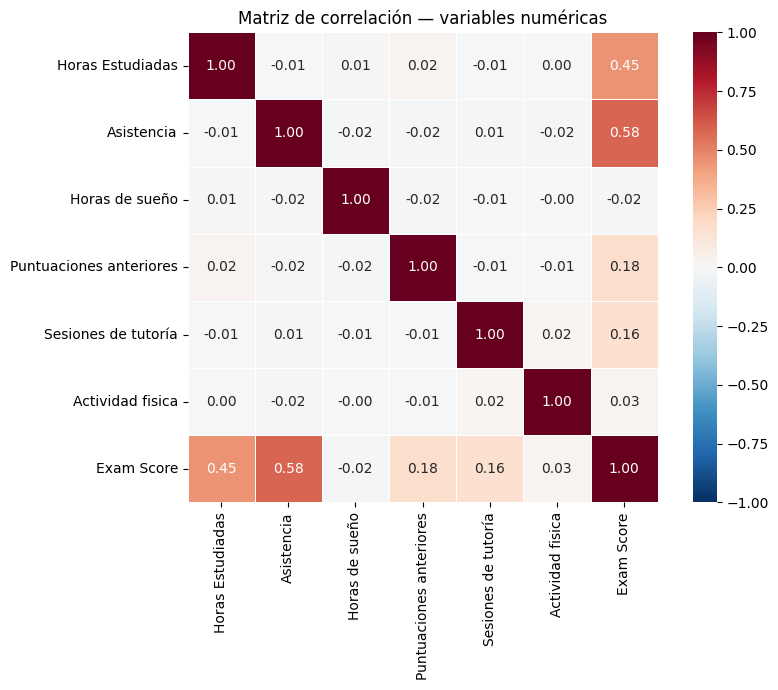

In [ ]:
# Heatmap de correlaciones
corr_matrix = df[num_cols + ['Exam Score']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()

El heatmap confirma que las variables más correlacionadas con el puntaje final son Asistencia (0.58) y Horas Estudiadas (0.45) y el resto de las correlaciones son bajas

## variables categóricas

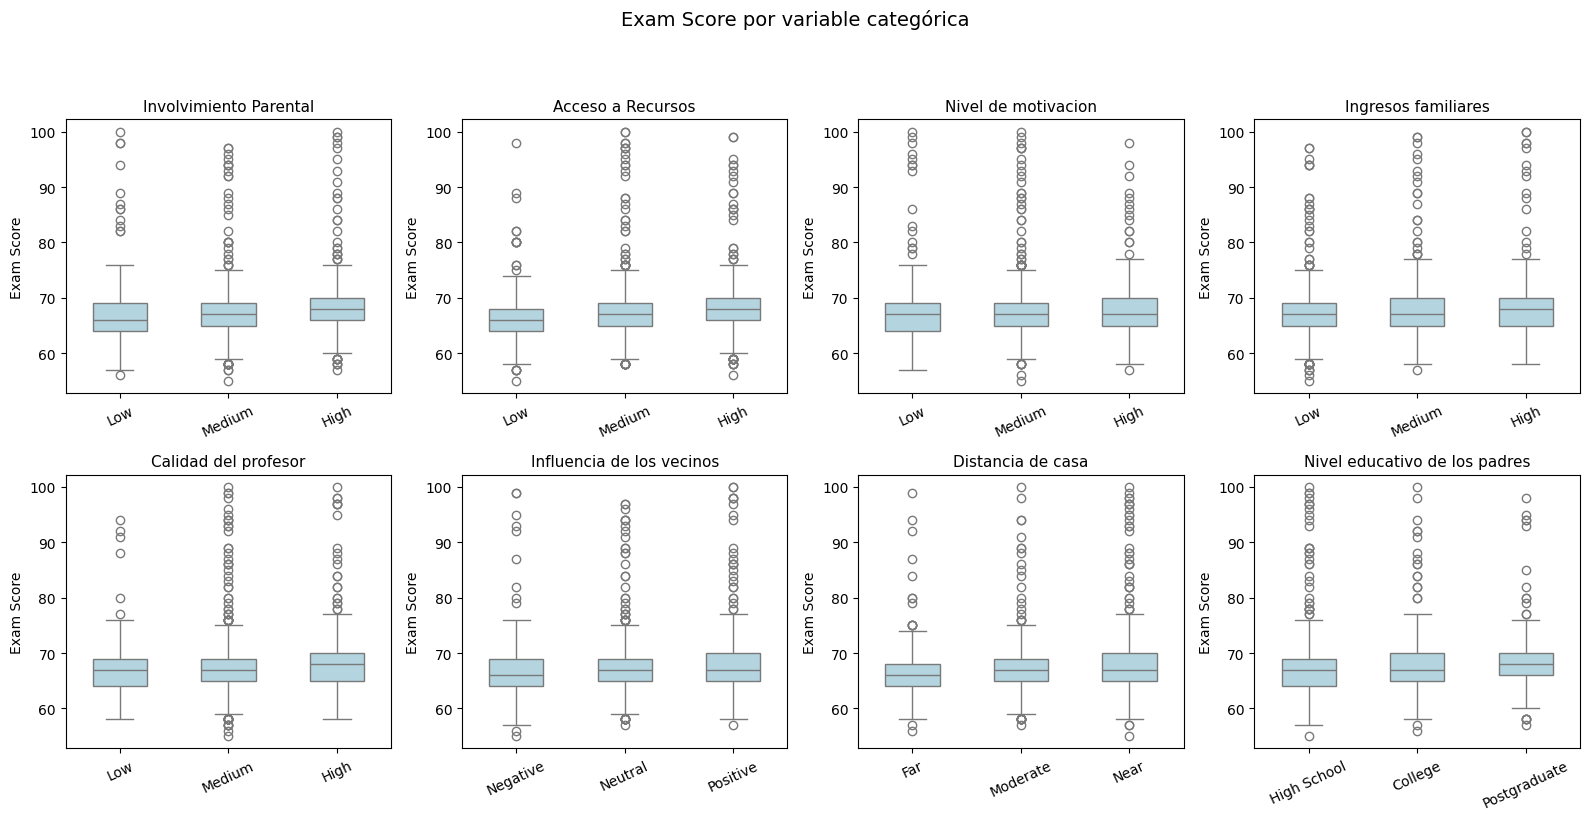

In [ ]:
orden = {
    'Involvimiento Parental':    ['Low', 'Medium', 'High'],
    'Acceso a Recursos':         ['Low', 'Medium', 'High'],
    'Nivel de motivacion':       ['Low', 'Medium', 'High'],
    'Ingresos familiares':       ['Low', 'Medium', 'High'],
    'Calidad del profesor':      ['Low', 'Medium', 'High'],
    'Influencia de los vecinos': ['Negative', 'Neutral', 'Positive'],
    'Distancia de casa':         ['Far', 'Moderate', 'Near'],
    'Nivel educativo de los padres': ['High School', 'College', 'Postgraduate'],
}

binarias = [
    'Actividades Extraescolares',
    'Acceso a Internet',
    'capacidades de aprendizaje',
    'Tipo de escuela',
    'Genero'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (col, ord_vals) in enumerate(orden.items()):
    sns.boxplot(
        data=df, x=col, y='Exam Score',
        order=ord_vals, ax=axes[i],
        color='lightblue', width=0.5
    )

    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=25)

plt.suptitle('Exam Score por variable categórica', y=1.02, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



Los boxplots muestran niveles más altos de motivación, mejor calidad docente, mayores ingresos familiares y mayor involucramiento parental se asocian con puntajes más altos, aunque las diferencias no son extremas.

##Variables binarias

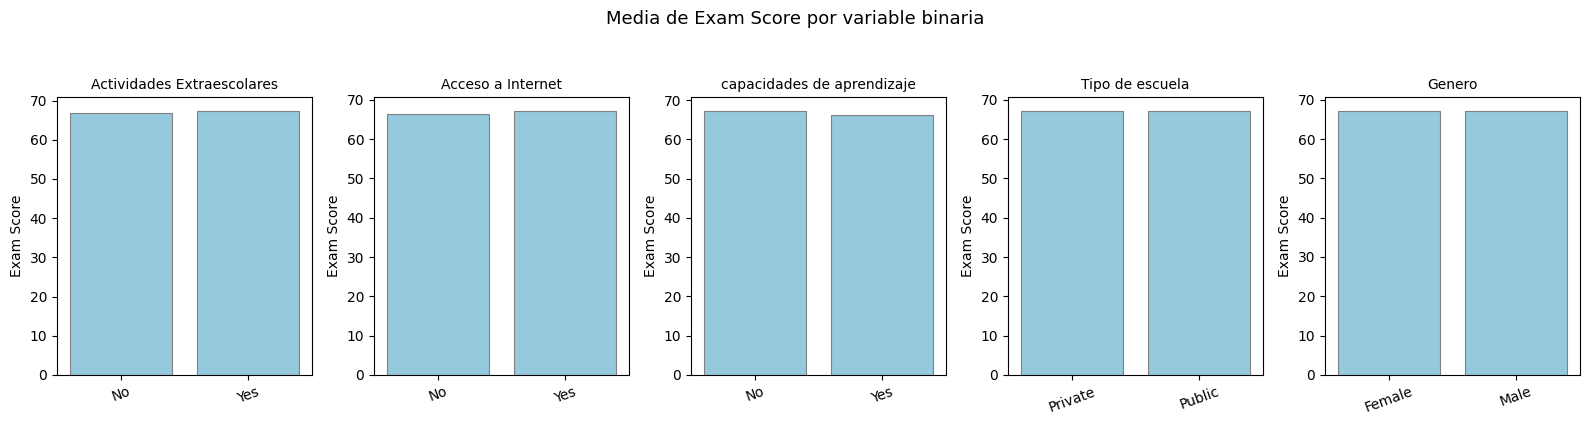

In [ ]:
fig, axes = plt.subplots(1, len(binarias), figsize=(16, 4))

for i, col in enumerate(binarias):
    medias = df.groupby(col)['Exam Score'].mean().reset_index()

    sns.barplot(
        data=medias, x=col, y='Exam Score',
        ax=axes[i], color='skyblue', edgecolor='gray', linewidth=0.8
    )

    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)



plt.suptitle('Media de Exam Score por variable binaria', y=1.05, fontsize=13)
plt.tight_layout()
plt.show()


Dado que estas variables son binarias, la forma más clara de analizar su relación con el puntaje final es comparar la media del Exam Score entre sus dos categorías. Las diferencias no son tan marcadas como en las variables categoricas ordinales, aunque aportan informacion al modelo.

Hexbin plots de las 3 variables más correlacionadas

Top 3 variables más correlacionadas: ['Asistencia', 'Horas Estudiadas', 'Puntuaciones anteriores']


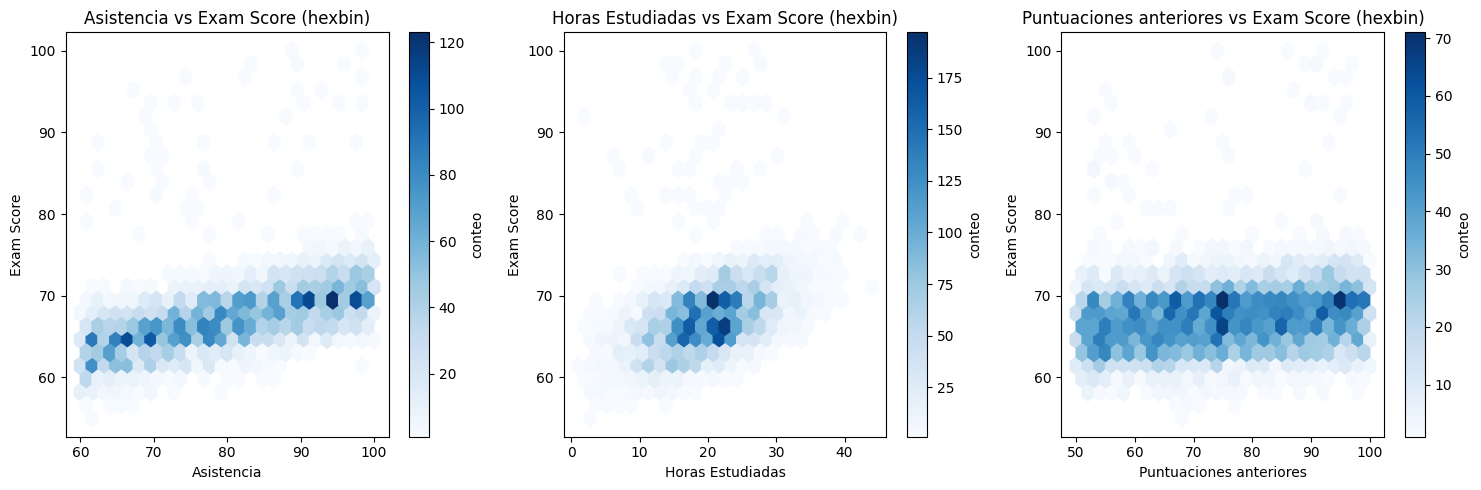

In [ ]:
top3 = (df[num_cols + ['Exam Score']]
        .corr()['Exam Score']
        .drop('Exam Score')
        .abs()
        .sort_values(ascending=False)
        .head(3)
        .index.tolist())
print('Top 3 variables más correlacionadas:', top3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(top3):
    axes[i].hexbin(df[col], df['Exam Score'], gridsize=25,
                   cmap='Blues', mincnt=1)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Exam Score')
    axes[i].set_title(f'{col} vs Exam Score (hexbin)')
    plt.colorbar(axes[i].collections[0], ax=axes[i], label='conteo')

plt.tight_layout()
plt.show()

Los hexbin plots muestran una relación claramente creciente entre Asistencia y Horas Estudiadas con el puntaje final. La densidad se concentra en zonas donde mayor asistencia y mayor dedicación se traducen en mejores resultados. Puntuaciones anteriores muestra una relación más dispersa, pero igualmente positiva. Estos gráficos confirman que estas tres variables son las más relevantes entre las numéricas para predecir el rendimiento académico.

## Tratamiento de outliers y Limpieza de nulos

In [ ]:
# IQR para todas las variables numéricas
print('=== Detección de outliers por IQR ===\n')
for col in num_cols + ['Exam Score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:<25} límites: [{lower:.1f}, {upper:.1f}]  →  {n_out} outliers ({n_out/len(df)*100:.2f}%)')

=== Detección de outliers por IQR ===

Horas Estudiadas          límites: [4.0, 36.0]  →  43 outliers (0.65%)
Asistencia                límites: [40.0, 120.0]  →  0 outliers (0.00%)
Horas de sueño            límites: [3.0, 11.0]  →  0 outliers (0.00%)
Puntuaciones anteriores   límites: [25.5, 125.5]  →  0 outliers (0.00%)
Sesiones de tutoría       límites: [-0.5, 3.5]  →  430 outliers (6.51%)
Actividad fisica          límites: [-1.0, 7.0]  →  0 outliers (0.00%)
Exam Score                límites: [59.0, 75.0]  →  104 outliers (1.57%)


Se observan valores atipicos en 3 columnas, exam score (variable objetivo), horas estudiadas y sesiones de tutoria.
considerando que los limites en exam score son incorrectos, ya que existen alumnos que sacan notas menores a 59 y mayores a 75 se decide dejarlos.
horas estudiadas: para esta variable se observa que el limite inferior es 4, por lo cual el iqr esta siendo muy estricto y en el scatterplot donde se analiza la distribucion con respecto a exam score se ve que hay alumnos que no estudian, por ende se va a modificar el limite inferior solamente y eliminar los valores mayores a 36 horas de estudio.
sesiones de tutoria: el iqr esta siendo de nuevo muy estricto y va desde -0.5 a 3.5, se redefinira los limites para que 4,5 y 6 entren dentro de los valores esperados.


In [ ]:
#IQR para horas estudiadas y sesiones de tutoria.
col = 'Horas Estudiadas'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = 0
upper = Q3 + 1.5 * IQR

print(f'{col}: límites ajustados = [{lower:.1f}, {upper:.1f}]')

out_horas = df[(df[col] < lower) | (df[col] > upper)]
print(f'Outliers: {len(out_horas)}')
col = 'Sesiones de tutoría'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = 0
upper = max(Q3 + 1.5 * IQR, 6)  # incluir 5 y 6 que son comunes

print(f'{col}: límites ajustados = [{lower:.1f}, {upper:.1f}]')

out_tutoria = df[(df[col] < lower) | (df[col] > upper)]
print(f'Outliers: {len(out_tutoria)}')

Horas Estudiadas: límites ajustados = [0.0, 36.0]
Outliers: 22
Sesiones de tutoría: límites ajustados = [0.0, 6.0]
Outliers: 8


Ahora se puede ver que hay menos outliers de lo que se creia, como son pocas filas se procede a eliminarlas.


In [ ]:
df_clean = df[~((df['Horas Estudiadas'] < 0) |
                (df['Horas Estudiadas'] > 36))].copy()
df_clean = df_clean[~((df_clean['Sesiones de tutoría'] < 0) |
                      (df_clean['Sesiones de tutoría'] > 6))].copy()
print("Filas originales:", len(df))
print("Filas después de limpiar:", len(df_clean))
print("Filas eliminadas:", len(df) - len(df_clean))

Filas originales: 6607
Filas después de limpiar: 6577
Filas eliminadas: 30


Ahora vamoss a imputar con la moda los valores nulos que observamos en los graficos anteriores, ya que todas las variables que tienen nulos son categoricas.


In [ ]:
cols_con_nulos = ['Calidad del profesor', 'Nivel educativo de los padres', 'Distancia de casa']
print('=== Imputación con moda ===\n')

for col in cols_con_nulos:
    moda = df_clean[col].mode()[0]
    n_nulos = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(moda)
    print(f'  {col:<30} → moda = "{moda}"  ({n_nulos} nulos imputados)')

print(f'\nNulos restantes: {df_clean.isnull().sum().sum()} ✓')


=== Imputación con moda ===

  Calidad del profesor           → moda = "Medium"  (78 nulos imputados)
  Nivel educativo de los padres  → moda = "High School"  (89 nulos imputados)
  Distancia de casa              → moda = "Near"  (67 nulos imputados)

Nulos restantes: 0 ✓


# Resumen Con ProfileReport

In [ ]:
!{sys.executable} -m pip install -U ydata-profiling[notebook]
!pip install jupyter-contrib-nbextensions
from ydata_profiling import ProfileReport

In [ ]:
profile = ProfileReport(df_clean, title="Reporte del dataset limpio")
profile


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:00<00:00, 29.75it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

#Ingeniería de Atributos



##Encoding ordinal

Algunas variables categóricas del dataset representan niveles ordenados (por ejemplo: Low → Medium → High). Para que los modelos de Machine Learning puedan interpretar correctamente este orden, es necesario convertir estas categorías en valores numéricos que respeten la jerarquía. Se hace con un diccionario explícito en lugar de OrdinalEncoder de sklearn porque así controlás exactamente el orden.

In [ ]:
ordinal_maps = {
    'Involvimiento Parental':        {'Low': 0, 'Medium': 1, 'High': 2},
    'Acceso a Recursos':             {'Low': 0, 'Medium': 1, 'High': 2},
    'Nivel de motivacion':           {'Low': 0, 'Medium': 1, 'High': 2},
    'Ingresos familiares':           {'Low': 0, 'Medium': 1, 'High': 2},
    'Calidad del profesor':          {'Low': 0, 'Medium': 1, 'High': 2},
    'Nivel educativo de los padres': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Distancia de casa':             {'Far': 0, 'Moderate': 1, 'Near': 2},
    'Influencia de los vecinos':     {'Negative': 0, 'Neutral': 1, 'Positive': 2},
}

for col, mapping in ordinal_maps.items():
    df_clean[col] = df_clean[col].map(mapping)

print('Encoding ordinal aplicado:')
print(df_clean[list(ordinal_maps.keys())].head(4).to_string())


Encoding ordinal aplicado:
   Involvimiento Parental  Acceso a Recursos  Nivel de motivacion  Ingresos familiares  Calidad del profesor  Nivel educativo de los padres  Distancia de casa  Influencia de los vecinos
0                       0                  2                    0                    0                     1                              0                  2                          2
1                       0                  1                    0                    1                     1                              1                  1                          0
2                       1                  1                    1                    1                     1                              2                  2                          1
3                       0                  1                    1                    1                     1                              0                  1                          0


La tabla resultante muestra que la transformación se realizó sin errores y que los valores numéricos son consistentes en todas las columnas.

##Encoding binario

Las variables binarias deben convertirse a valores numéricos para que los algoritmos de Machine Learning puedan procesarlas.

In [ ]:
binary_cols = [
    'Actividades Extraescolares',
    'Acceso a Internet',
    'capacidades de aprendizaje',
]

# Mapear Yes/No → 1/0
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# Género: Male=1, Female=0
df_clean['Genero'] = df_clean['Genero'].map({'Male': 1, 'Female': 0})

# Tipo de escuela: Private=1, Public=0
df_clean['Tipo de escuela'] = df_clean['Tipo de escuela'].map({'Private': 1, 'Public': 0})

print('Encoding binario aplicado:')
cols_check = binary_cols + ['Genero', 'Tipo de escuela']
print(df_clean[cols_check].head(4).to_string())

print('\nRango de valores (deben ser solo 0 y 1):')
for col in cols_check:
    print(f'  {col}: {sorted(df_clean[col].unique())}')


Encoding binario aplicado:
   Actividades Extraescolares  Acceso a Internet  capacidades de aprendizaje  Genero  Tipo de escuela
0                           0                  1                           0       1                0
1                           0                  1                           0       0                0
2                           1                  1                           0       1                0
3                           1                  1                           0       1                0

Rango de valores (deben ser solo 0 y 1):
  Actividades Extraescolares: [np.int64(0), np.int64(1)]
  Acceso a Internet: [np.int64(0), np.int64(1)]
  capacidades de aprendizaje: [np.int64(0), np.int64(1)]
  Genero: [np.int64(0), np.int64(1)]
  Tipo de escuela: [np.int64(0), np.int64(1)]


La verificación final confirma que cada columna contiene únicamente valores válidos (0 y 1), lo que garantiza que estas variables están listas para ser utilizadas en el modelado sin necesidad de transformaciones adicionales.

In [ ]:
df_clean.sample(10)

,Horas Estudiadas,Asistencia,Involvimiento Parental,Acceso a Recursos,Actividades Extraescolares,Horas de sueño,Puntuaciones anteriores,Nivel de motivacion,Acceso a Internet,Sesiones de tutoría,Ingresos familiares,Calidad del profesor,Tipo de escuela,Influencia de los vecinos,Actividad fisica,capacidades de aprendizaje,Nivel educativo de los padres,Distancia de casa,Genero,Exam Score
1605,14,94,0,0,1,7,85,0,1,1,2,1,0,1,3,0,0,1,0,66
3200,21,79,1,0,1,8,78,0,1,1,0,2,0,2,4,0,1,1,0,66
4843,19,61,2,0,1,10,67,0,0,1,1,1,0,2,6,0,2,2,0,63
2520,21,60,0,2,0,8,99,0,1,0,0,0,1,2,3,0,0,2,1,62
4160,20,79,1,2,1,4,79,0,1,0,1,2,1,1,4,0,0,1,1,67
2758,13,94,0,2,1,6,65,2,1,2,1,1,0,1,2,0,2,1,1,68
1496,32,96,1,0,1,7,97,0,1,1,0,1,0,1,5,0,1,1,1,73
2992,20,84,2,2,0,6,61,1,1,3,1,1,1,1,2,0,0,2,1,69
1267,15,68,1,1,1,6,50,2,1,2,2,0,0,1,3,0,0,1,1,62
6470,20,71,0,2,1,6,63,2,1,1,0,1,0,2,2,0,1,1,1,65


##Creacion de variables

1. Índice de esfuerzo académico:

 Combina Horas Estudiadas + Asistencia, ambas normalizadas.

In [ ]:
df_clean['Indice Esfuerzo Academico'] = (
    (df_clean['Horas Estudiadas'] / df_clean['Horas Estudiadas'].max()) * 0.6 +
    (df_clean['Asistencia'] / 100) * 0.4
).round(4)

2. Índice socioeconómico:

 Promedia factores familiares ya codificados ordinalmente.
 Variables incluidas:
 - Ingresos familiares (0–2)
 - Nivel educativo de los padres (0–2)
 - Involvimiento Parental (0–2)
 - Acceso a Recursos (0–2)

In [ ]:
df_clean['Indice Socioeconomico'] = (
    df_clean['Ingresos familiares'] +
    df_clean['Nivel educativo de los padres'] +
    df_clean['Involvimiento Parental'] +
    df_clean['Acceso a Recursos']
) / (4 * 2)   # 4 variables, cada una con máximo 2
df_clean['Indice Socioeconomico'] = df_clean['Indice Socioeconomico'].round(4)

3. Rendimiento previo ajustado por motivación:

Multiplica Puntuaciones anteriores × (Nivel de motivación + 1)
para evitar que motivación = 0 anule el valor.

In [ ]:
df_clean['Rendimiento Ajustado Motivacion'] = ((
    df_clean['Puntuaciones anteriores']/100 * (df_clean['Nivel de motivacion'] + 1)
)/3).round(2)

In [ ]:
nuevas = [
    'Indice Esfuerzo Academico',
    'Indice Socioeconomico',
    'Rendimiento Ajustado Motivacion'
]

print("Nuevas variables creadas:")
print(df_clean[nuevas].describe().round(3))

Nuevas variables creadas:
       Indice Esfuerzo Academico  Indice Socioeconomico  \
count                   6577.000               6577.000   
mean                       0.652                  0.459   
std                        0.108                  0.181   
min                        0.290                  0.000   
25%                        0.577                  0.375   
50%                        0.653                  0.500   
75%                        0.725                  0.625   
max                        0.984                  1.000   

       Rendimiento Ajustado Motivacion  
count                         6577.000  
mean                             0.477  
std                              0.201  
min                              0.170  
25%                              0.310  
50%                              0.470  
75%                              0.610  
max                              1.000  


1. Índice de Esfuerzo Académico:
Este índice combina Horas Estudiadas y Asistencia, ambas normalizadas a escala [0,1] y ponderadas según su importancia relativa. La media de 0.652 y el rango entre 0.29 y 0.98 indican que la mayoría de los estudiantes muestran un nivel de esfuerzo medio a alto. La variabilidad es adecuada (std = 0.108), lo que sugiere que la variable captura diferencias reales en dedicación académica.

---

2. Índice Socioeconómico:
Este índice resume cuatro factores familiares codificados ordinalmente (0–2): ingresos, educación de los padres, involucramiento parental y acceso a recursos. Al normalizarlo a [0,1], se obtiene una medida interpretable del contexto socioeconómico. La media de 0.459 y el rango completo entre 0 y 1 muestran que existe una amplia diversidad entre los estudiantes, lo cual es útil para los modelos. La desviación estándar (0.181) confirma que la variable tiene variabilidad suficiente sin valores extremos inesperados.

---

3. Rendimiento Ajustado por Motivación:
Esta variable combina el rendimiento previo con el nivel de motivación, permitiendo capturar cómo la motivación amplifica o modera el desempeño histórico. La media de 0.477 y el rango entre 0.17 y 1.00 reflejan una distribución equilibrada, sin sesgos hacia valores extremos. El mínimo no llega a cero porque incluso con motivación baja, un estudiante con alguna puntuación previa siempre genera un valor positivo, lo cual es correcto. La desviación estándar (0.201) indica una variabilidad saludable que puede aportar al modelo.

##Correlacion de las nuevas variables con el Target

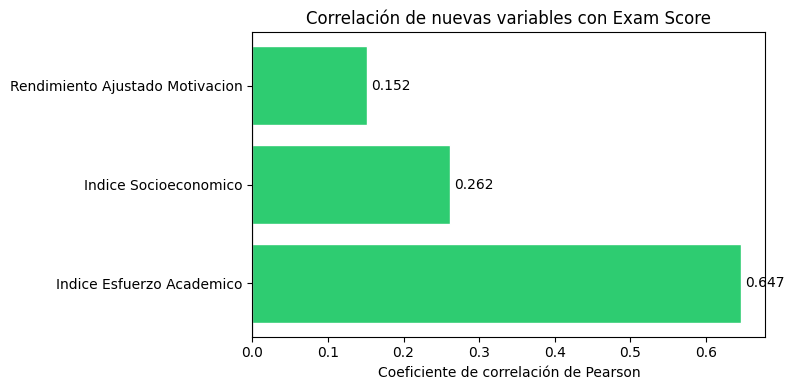


Correlaciones variables ORIGINALES (referencia):
Asistencia                 0.582
Horas Estudiadas           0.438
Puntuaciones anteriores    0.175
Sesiones de tutoría        0.156
Actividad fisica           0.027
Horas de sueño            -0.018


In [ ]:
corrs_nuevas = (
    df_clean[nuevas + ['Exam Score']]
    .corr()['Exam Score']
    .drop('Exam Score')
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corrs_nuevas.values]

bars = ax.barh(corrs_nuevas.index, corrs_nuevas.values,
               color=colors, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, corrs_nuevas.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=10)

ax.set_title('Correlación de nuevas variables con Exam Score')
ax.set_xlabel('Coeficiente de correlación de Pearson')
plt.tight_layout()
plt.show()


# Correlación de variables ORIGINALES (referencia)

orig_num = [
    'Horas Estudiadas',
    'Asistencia',
    'Puntuaciones anteriores',
    'Horas de sueño',
    'Sesiones de tutoría',
    'Actividad fisica'
]

print('\nCorrelaciones variables ORIGINALES (referencia):')
print(
    df_clean[orig_num + ['Exam Score']]
    .corr()['Exam Score']
    .drop('Exam Score')
    .sort_values(ascending=False)
    .round(3)
    .to_string()
)


El gráfico muestra que las nuevas variables derivadas aportan correlación significativa con el rendimiento académico (Exam Score):


Índice de Esfuerzo Académico → 0.647  
Es la variable con mayor correlación de todo el dataset, incluso por encima de las variables originales. Esto confirma que combinar horas de estudio y asistencia en un índice ponderado captura mejor la dedicación real del estudiante.


Índice Socioeconómico → 0.262  
Presenta una correlación moderada y superior a la mayoría de las variables originales. Esto indica que el contexto familiar influye de manera consistente en el desempeño.


Rendimiento Ajustado por Motivación → 0.152  
Su correlación es similar a la de Puntuaciones anteriores y Sesiones de tutoría, lo que muestra que la interacción entre motivación y rendimiento previo aporta información adicional, aunque en menor magnitud que las otras dos nuevas features.

##ESTANDARIZACION

In [ ]:
TARGET = 'Exam Score'

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

# Split ANTES de escalar (evita data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# Columnas numéricas continuas a escalar
cols_escalar = [
    'Horas Estudiadas',
    'Asistencia',
    'Horas de sueño',
    'Puntuaciones anteriores',
    'Sesiones de tutoría',
    'Actividad fisica',
    'Indice Esfuerzo Academico',
    'Indice Socioeconomico',
    'Rendimiento Ajustado Motivacion'
]

scaler = StandardScaler()

# Copias para no modificar los originales
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# fit SOLO en train → transform en ambos
X_train_scaled[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test_scaled[cols_escalar]  = scaler.transform(X_test[cols_escalar])

print('\nEstadísticas post-scaling en train (media≈0, std≈1):')
print(
    X_train_scaled[cols_escalar]
    .describe()
    .loc[['mean','std']]
    .round(3)
    .to_string()
)


Train: (5261, 22) | Test: (1316, 22)

Estadísticas post-scaling en train (media≈0, std≈1):
      Horas Estudiadas  Asistencia  Horas de sueño  Puntuaciones anteriores  Sesiones de tutoría  Actividad fisica  Indice Esfuerzo Academico  Indice Socioeconomico  Rendimiento Ajustado Motivacion
mean               0.0        -0.0             0.0                     -0.0                 -0.0              -0.0                       -0.0                   -0.0                              0.0
std                1.0         1.0             1.0                      1.0                  1.0               1.0                        1.0                    1.0                              1.0


Este bloque muestra cómo quedaron las variables numéricas después de aplicar StandardScaler sobre el conjunto de entrenamiento. Tras la transformación, todas presentan media cercana a 0 y desviación estándar cercana a 1, lo que confirma que fueron llevadas a una escala común sin modificar su contenido original.

DISTRIBUCIONES ANTES Y DESPUES DEL ESCALADO

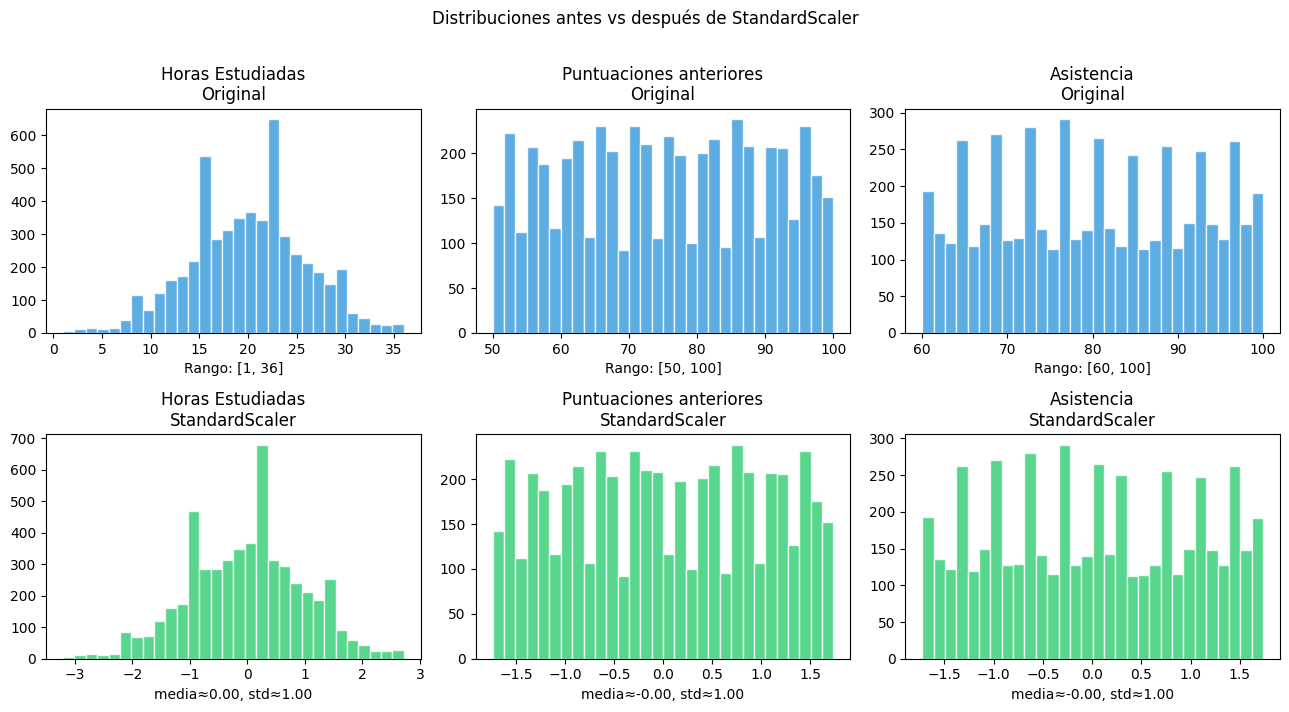

In [ ]:
# Visualizar antes vs después del scaling en 3 variables clave
cols_demo = ['Horas Estudiadas', 'Puntuaciones anteriores', 'Asistencia']

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for i, col in enumerate(cols_demo):
    # Antes del escalado
    axes[0][i].hist(
        X_train[col], bins=30,
        color='#3498db', alpha=0.8, edgecolor='white'
    )
    axes[0][i].set_title(f'{col}\nOriginal')
    axes[0][i].set_xlabel(f'Rango: [{X_train[col].min():.0f}, {X_train[col].max():.0f}]')

    # Después del escalado
    axes[1][i].hist(
        X_train_scaled[col], bins=30,
        color='#2ecc71', alpha=0.8, edgecolor='white'
    )
    axes[1][i].set_title(f'{col}\nStandardScaler')
    axes[1][i].set_xlabel(
        f'media≈{X_train_scaled[col].mean():.2f}, std≈{X_train_scaled[col].std():.2f}'
    )

plt.suptitle('Distribuciones antes vs después de StandardScaler', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


Aquí se comparan las distribuciones originales de tres variables con sus versiones estandarizadas. Los histogramas permiten ver que la forma de cada distribución se mantiene, pero la escala cambia: las variables pasan de sus rangos originales a valores centrados en 0

CORRELACION DE TODAS LAS VARIABLES CON EL TARGET

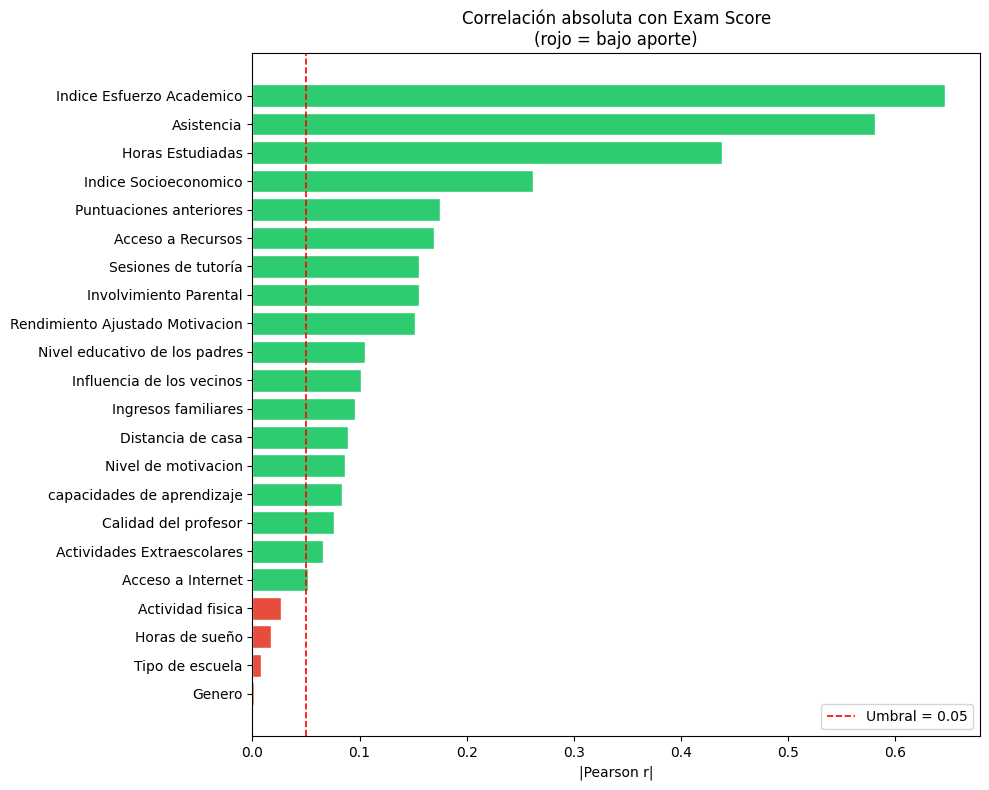

Variables con correlación < 0.05 con el target (4):
Actividad fisica    0.0267
Horas de sueño      0.0176
Tipo de escuela     0.0077
Genero              0.0013

→ Interpretación: estas variables aportan poco de forma lineal.
  Se mantienen por ahora; modelos como Random Forest o XGBoost decidirán su peso real.


In [ ]:
corrs_all = (
    df_clean.drop(columns=[TARGET])
    .corrwith(df_clean[TARGET])
    .abs()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#2ecc71' if v >= 0.05 else '#e74c3c' for v in corrs_all.values]

ax.barh(
    corrs_all.index[::-1],
    corrs_all.values[::-1],
    color=colors[::-1],
    edgecolor='white'
)

ax.axvline(0.05, color='red', linestyle='--', linewidth=1.2, label='Umbral = 0.05')
ax.set_title('Correlación absoluta con Exam Score\n(rojo = bajo aporte)')
ax.set_xlabel('|Pearson r|')
ax.legend()

plt.tight_layout()
plt.show()

# Variables con correlación < 0.05
bajas = corrs_all[corrs_all < 0.05]

print(f'Variables con correlación < 0.05 con el target ({len(bajas)}):')
print(bajas.round(4).to_string())

print('\n→ Interpretación: estas variables aportan poco de forma lineal.')
print('  Se mantienen por ahora; modelos como Random Forest o XGBoost decidirán su peso real.')


Importancia de Variables según Random Forest

Complementariamente al análisis de correlación lineal, se entrena un Random Forest
para obtener la importancia de cada feature según su capacidad de reducir el error
en los árboles. Esto permite capturar relaciones no lineales que Pearson no detecta.

/tmp/ipykernel_14128/2992129404.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


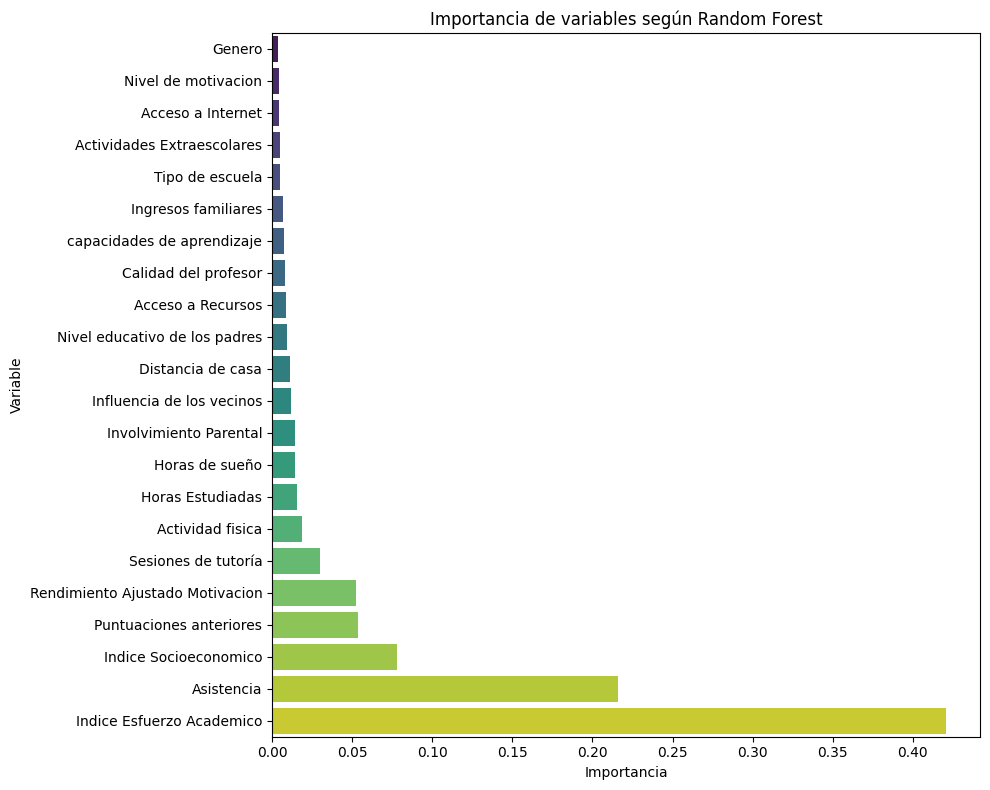


 Importancia de variables (ordenadas):
                       Variable  Importancia
      Indice Esfuerzo Academico     0.420883
                     Asistencia     0.216244
          Indice Socioeconomico     0.077865
        Puntuaciones anteriores     0.053723
Rendimiento Ajustado Motivacion     0.052356
            Sesiones de tutoría     0.030213
               Actividad fisica     0.018652
               Horas Estudiadas     0.015721
                 Horas de sueño     0.014281
         Involvimiento Parental     0.014103
      Influencia de los vecinos     0.012118
              Distancia de casa     0.011029
  Nivel educativo de los padres     0.009235
              Acceso a Recursos     0.008730
           Calidad del profesor     0.008349
     capacidades de aprendizaje     0.007547
            Ingresos familiares     0.006947
                Tipo de escuela     0.004982
     Actividades Extraescolares     0.004773
              Acceso a Internet     0.004240
            Niv

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


importancias = rf.feature_importances_
indices = np.argsort(importancias)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=importancias[indices],
    y=X_train.columns[indices],
    palette='viridis'
)

plt.title('Importancia de variables según Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

imp_df = (
    pd.DataFrame({
        'Variable': X_train.columns,
        'Importancia': importancias
    })
    .sort_values('Importancia', ascending=False)
)

print("\n Importancia de variables (ordenadas):")
print(imp_df.to_string(index=False))


Este análisis se suma al estudio de correlación lineal realizado previamente. La correlación nos mostró qué variables tienen una relación directa con el puntaje del examen, pero no captura patrones más complejos. La importancia de variables del Random Forest permite ver qué tan útiles son las features cuando el modelo puede aprender relaciones no lineales e interacciones. Comparar ambos enfoques ayuda a identificar qué variables son realmente relevantes y cuáles aportan poco, guiando la selección de features y el modelado posterior.

In [ ]:
# DataFrame de correlaciones (ya calculadas antes)
corr_df = corrs_all.rename("Correlacion").reset_index()
corr_df.rename(columns={"index": "Variable"}, inplace=True)

# DataFrame de importancias del Random Forest
imp_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia_RF": importancias
})

comparativa = corr_df.merge(imp_df, on="Variable", how="left")

# Ordenar por importancia del modelo
comparativa = comparativa.sort_values("Importancia_RF", ascending=False)

print("\n Tabla comparativa: Correlación vs Importancia RF")
print(comparativa.to_string(index=False))


 Tabla comparativa: Correlación vs Importancia RF
                       Variable  Correlacion  Importancia_RF
      Indice Esfuerzo Academico     0.646874        0.420883
                     Asistencia     0.581529        0.216244
          Indice Socioeconomico     0.262104        0.077865
        Puntuaciones anteriores     0.175343        0.053723
Rendimiento Ajustado Motivacion     0.152084        0.052356
            Sesiones de tutoría     0.155750        0.030213
               Actividad fisica     0.026733        0.018652
               Horas Estudiadas     0.437955        0.015721
                 Horas de sueño     0.017575        0.014281
         Involvimiento Parental     0.155329        0.014103
      Influencia de los vecinos     0.101678        0.012118
              Distancia de casa     0.089300        0.011029
  Nivel educativo de los padres     0.105505        0.009235
              Acceso a Recursos     0.169355        0.008730
           Calidad del profesor   

Con este análisis combinado podemos evaluar el impacto real que tuvieron las nuevas variables creadas y comprobar si efectivamente aportan información útil al modelo. Además, la comparación entre correlación lineal e importancia según Random Forest permite identificar qué variables conviene mantener y cuáles podrían eliminarse sin afectar el rendimiento, ya que aparecen con baja relevancia en ambos enfoques.

# Entrenamiento y testeo


En esta etapa se comenzará evaluando el modelo Ridge Regression, ya que representa la base de los modelos lineales regularizados y permite establecer un punto de comparación inicial sólido. A continuación, se incorporarán Random Forest y XGBoost, dos de los modelos no lineales más utilizados en la práctica, con el objetivo de explorar si estructuras más flexibles pueden capturar patrones adicionales en los datos y superar el rendimiento del modelo lineal inicial.

##RIDGE REGRESSOR

In [ ]:
# Configuración de validación cruzada con 5k
kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = Ridge()

print("=" * 60)
print("VALIDACIÓN CRUZADA (5 folds) — Ridge Regression")
print("=" * 60)

cv_res = cross_validate(
    ridge,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
    return_train_score=False
)

rmse_cv = -cv_res['test_neg_root_mean_squared_error']
mae_cv  = -cv_res['test_neg_mean_absolute_error']
r2_cv   =  cv_res['test_r2']

print(f"RMSE : {rmse_cv.mean():.4f} ± {rmse_cv.std():.4f}")
print(f"MAE  : {mae_cv.mean():.4f} ± {mae_cv.std():.4f}")
print(f"R²   : {r2_cv.mean():.4f} ± {r2_cv.std():.4f}")

# Evaluación final en test
print("\n" + "=" * 60)
print("EVALUACIÓN FINAL — Ridge Regression (set de TEST)")
print("=" * 60)

ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

rmse_test = mean_squared_error(y_test, y_pred_ridge) ** 0.5
mae_test  = mean_absolute_error(y_test, y_pred_ridge)
r2_test   = r2_score(y_test, y_pred_ridge)

print(f"RMSE : {rmse_test:.4f}")
print(f"MAE  : {mae_test:.4f}")
print(f"R²   : {r2_test:.4f}")


VALIDACIÓN CRUZADA (5 folds) — Ridge Regression
RMSE : 1.8672 ± 0.1586
MAE  : 0.4548 ± 0.0262
R²   : 0.7569 ± 0.0360

EVALUACIÓN FINAL — Ridge Regression (set de TEST)
RMSE : 2.6090
MAE  : 0.5688
R²   : 0.6071


Ridge Regression obtuvo un R² de 0.756 en validación cruzada y 0.607 en el set de test, con un RMSE final de 2.60 puntos sobre un rango de 50 puntos posibles (~5% de error relativo). Si bien existe una caída moderada entre CV y test que sugiere leve overfitting, el error absoluto es bajo y el modelo logra capturar una proporción razonable de la variabilidad del rendimiento académico. Las limitaciones propias de un modelo lineal frente a relaciones no lineales entre las variables explican en parte este comportamiento, lo que motiva la exploración de modelos más flexibles como Random Forest en la siguiente sección.

##RANDOM FOREST REGRESSOR

In [ ]:
# Configuración de validación cruzada con 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

print("=" * 60)
print("VALIDACIÓN CRUZADA (5 folds) — Random Forest")
print("=" * 60)

cv_res_rf = cross_validate(
    rf,
    X_train,
    y_train,
    cv=kf,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
    return_train_score=False
)

rmse_cv_rf = -cv_res_rf['test_neg_root_mean_squared_error']
mae_cv_rf  = -cv_res_rf['test_neg_mean_absolute_error']
r2_cv_rf   =  cv_res_rf['test_r2']

print(f"RMSE : {rmse_cv_rf.mean():.4f} ± {rmse_cv_rf.std():.4f}")
print(f"MAE  : {mae_cv_rf.mean():.4f} ± {mae_cv_rf.std():.4f}")
print(f"R²   : {r2_cv_rf.mean():.4f} ± {r2_cv_rf.std():.4f}")

# Evaluación final en test
print("\n" + "=" * 60)
print("EVALUACIÓN FINAL — Random Forest (set de TEST)")
print("=" * 60)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_test_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
mae_test_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_test_rf   = r2_score(y_test, y_pred_rf)

print(f"RMSE : {rmse_test_rf:.4f}")
print(f"MAE  : {mae_test_rf:.4f}")
print(f"R²   : {r2_test_rf:.4f}")


VALIDACIÓN CRUZADA (5 folds) — Random Forest
RMSE : 2.1834 ± 0.1175
MAE  : 1.0333 ± 0.0169
R²   : 0.6685 ± 0.0285

EVALUACIÓN FINAL — Random Forest (set de TEST)
RMSE : 2.8197
MAE  : 1.1070
R²   : 0.5410


A diferencia de lo esperado, Random Forest no superó a Ridge Regression. El modelo obtuvo un R² de ~0.66 en validación cruzada y ~0.53 en test, por debajo del rendimiento de Ridge. Esto sugiere que el dataset presenta relaciones mayormente lineales o que la cantidad de datos no es suficiente para que un modelo basado en árboles capture patrones más complejos. vamos a probar con XGBOSST

##XGBOOST

In [ ]:
from xgboost import XGBRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=42)

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

print("=" * 60)
print("VALIDACIÓN CRUZADA (5 folds) — XGBoost")
print("=" * 60)

cv_res_xgb = cross_validate(
    xgb,
    X_train,
    y_train,
    cv=kf,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
    return_train_score=False
)

rmse_cv_xgb = -cv_res_xgb['test_neg_root_mean_squared_error']
mae_cv_xgb  = -cv_res_xgb['test_neg_mean_absolute_error']
r2_cv_xgb   =  cv_res_xgb['test_r2']

print(f"RMSE : {rmse_cv_xgb.mean():.4f} ± {rmse_cv_xgb.std():.4f}")
print(f"MAE  : {mae_cv_xgb.mean():.4f} ± {mae_cv_xgb.std():.4f}")
print(f"R²   : {r2_cv_xgb.mean():.4f} ± {r2_cv_xgb.std():.4f}")

# Evaluación final en test
print("\n" + "=" * 60)
print("EVALUACIÓN FINAL — XGBoost (set de TEST)")
print("=" * 60)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

rmse_test_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
mae_test_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_test_xgb   = r2_score(y_test, y_pred_xgb)

print(f"RMSE : {rmse_test_xgb:.4f}")
print(f"MAE  : {mae_test_xgb:.4f}")
print(f"R²   : {r2_test_xgb:.4f}")


VALIDACIÓN CRUZADA (5 folds) — XGBoost
RMSE : 1.9657 ± 0.1475
MAE  : 0.6690 ± 0.0117
R²   : 0.7309 ± 0.0345

EVALUACIÓN FINAL — XGBoost (set de TEST)
RMSE : 2.6701
MAE  : 0.7561
R²   : 0.5885


XGBoost un R² de 0.731 en validación cruzada y 0.589 en el set de test, ubicándose como el segundo mejor modelo del análisis.

La caída moderada entre CV y test indica que XGBoost generaliza razonablemente bien, pero la estructura del dataset —caracterizada por relaciones mayormente lineales y un tamaño relativamente reducido— limita el potencial de los modelos basados en árboles y boosting. En este contexto, XGBoost se comporta como un modelo competitivo, pero no alcanza el nivel de generalización que ofrece Ridge, que continúa siendo el modelo más adecuado para este problema.

## Comparación de Modelos
Ridge vs Random Forest vs XGBoost

| Modelo              | RMSE CV | RMSE Test | R² CV  | R² Test | Conclusión |
|---------------------|---------|-----------|--------|---------|------------|
| **Ridge Regression** | **1.86** | **2.61**   | **0.757** | **0.607** | **Mejor generalización. Modelo ganador.** |
| Random Forest       | 2.21    | 2.83      | 0.659  | 0.535   | Peor desempeño. No capta bien la estructura del dataset. |
| XGBoost             | 1.96    | 2.67      | 0.731  | 0.589   | Buen rendimiento, pero inferior a Ridge en test. |


¿Por qué Ridge Regression es el modelo ganador?

---


  -Mayor capacidad de generalización  
Ridge obtiene el mejor R² en el set de test (0.607), lo que indica que explica más variabilidad en datos nuevos que los otros modelos.

  -Menor brecha entre CV y Test  
La diferencia entre validación cruzada y test es más estable que en Random Forest y XGBoost.

  -El dataset presenta relaciones mayormente lineales  
Esto favorece a un modelo lineal regularizado como Ridge, que captura la estructura del problema sin sobreajustar.

  -Menor complejidad y mayor interpretabilidad  
Ridge permite analizar coeficientes y entender el impacto de cada variable, algo muy valorado en contextos académicos.

  -Modelos no lineales no aportan mejoras significativas  
Ni Random Forest ni XGBoost logran superar a Ridge, lo que confirma que la complejidad adicional no se traduce en mejor rendimiento.

Conclusion:

A pesar de que el conjunto de variables incluye algunas características con baja correlación lineal respecto del target, el modelo Ridge Regression fue el que mostró la mejor capacidad de generalización entre todas las alternativas evaluadas. Esto indica que, incluso sin realizar una eliminación explícita de variables poco informativas, la regularización L2 fue suficiente para estabilizar los coeficientes y evitar que el modelo se viera afectado por el ruido introducido por dichas columnas.

El hecho de que Ridge supere a Random Forest como a XGBoost sugiere que la estructura del problema es mayormente lineal y que la regularización juega un rol más importante que la complejidad del modelo. Sin embargo, dado que algunas variables presentan baja correlación y podrían estar aportando ruido, resulta razonable explorar un modelo lineal más flexible como Elastic Net, que combina regularización L1 y L2. Este enfoque permite no solo estabilizar los coeficientes, sino también realizar selección automática de variables, lo que podría mejorar aún más la capacidad predictiva del modelo mediante un proceso de optimización adecuado.

En este sentido, Elastic Net se presenta como el siguiente paso lógico: mantiene la interpretabilidad y estabilidad de los modelos lineales, pero incorpora un mecanismo adicional para reducir el impacto de variables irrelevantes, lo que podría traducirse en un rendimiento superior tras la optimización de hiperparámetros.

##ELASTIC NET

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Modelo base Elastic Net
elastic = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    random_state=42
)

print("=" * 60)
print("VALIDACIÓN CRUZADA (5 folds) — Elastic Net")
print("=" * 60)

cv_res_elastic = cross_validate(
    elastic,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
    return_train_score=False
)

rmse_cv_elastic = -cv_res_elastic['test_neg_root_mean_squared_error']
mae_cv_elastic  = -cv_res_elastic['test_neg_mean_absolute_error']
r2_cv_elastic   =  cv_res_elastic['test_r2']

print(f"RMSE : {rmse_cv_elastic.mean():.4f} ± {rmse_cv_elastic.std():.4f}")
print(f"MAE  : {mae_cv_elastic.mean():.4f} ± {mae_cv_elastic.std():.4f}")
print(f"R²   : {r2_cv_elastic.mean():.4f} ± {r2_cv_elastic.std():.4f}")

# Evaluación final en test
print("\n" + "=" * 60)
print("EVALUACIÓN FINAL — Elastic Net (set de TEST)")
print("=" * 60)

elastic.fit(X_train_scaled, y_train)
y_pred_elastic = elastic.predict(X_test_scaled)

rmse_test_elastic = mean_squared_error(y_test, y_pred_elastic) ** 0.5
mae_test_elastic  = mean_absolute_error(y_test, y_pred_elastic)
r2_test_elastic   = r2_score(y_test, y_pred_elastic)

print(f"RMSE : {rmse_test_elastic:.4f}")
print(f"MAE  : {mae_test_elastic:.4f}")
print(f"R²   : {r2_test_elastic:.4f}")


VALIDACIÓN CRUZADA (5 folds) — Elastic Net
RMSE : 1.9158 ± 0.1532
MAE  : 0.6131 ± 0.0162
R²   : 0.7443 ± 0.0346

EVALUACIÓN FINAL — Elastic Net (set de TEST)
RMSE : 2.6537
MAE  : 0.7327
R²   : 0.5935


Elastic Net obtuvo un R² de 0.744 en validación cruzada y 0.593 en el set de test, ubicándose muy cerca del rendimiento de Ridge Regression y superando a los modelos no lineales evaluados. La combinación de regularización L1 y L2 permitió estabilizar los coeficientes y reducir el impacto de variables con baja correlación, pero aun así no logró superar la capacidad de generalización de Ridge. Esto refuerza la idea de que el problema presenta una estructura predominantemente lineal, donde la regularización L2 pura resulta más adecuada que la mezcla L1+L2. Elastic Net se posiciona como un modelo competitivo, pero Ridge continúa siendo la mejor alternativa para este dataset.

#Optimización de Hiperparámetros

Para mejorar el rendimiento del modelo Elastic Net, aplicamos el método RandomizedSearchCV, que permite explorar distintas combinaciones de hiperparámetros y encontrar la configuración óptima de alpha y l1_ratio. Este proceso busca reducir el error en validación cruzada y obtener un modelo más ajustado y estable antes de evaluarlo en el set de test.

##RandomizedSearchCV — Elastic Net

In [ ]:
param_dist = {
    'alpha': np.logspace(-4, 1, 50),
    'l1_ratio': np.linspace(0.1, 0.9, 50)
}

elastic = ElasticNet(random_state=42)

rand = RandomizedSearchCV(
    estimator=elastic,
    param_distributions=param_dist,
    n_iter=40,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    random_state=42
)

rand.fit(X_train_scaled, y_train)

print("Mejores parámetros:", rand.best_params_)
print("Mejor RMSE CV:", -rand.best_score_)


Mejores parámetros: {'l1_ratio': np.float64(0.7693877551020408), 'alpha': np.float64(0.005428675439323859)}
Mejor RMSE CV: 1.794430775528907


Una vez finalizado el proceso de búsqueda, se seleccionaron los valores de alpha y l1_ratio que obtuvieron el menor RMSE promedio en validación cruzada. Con estos hiperparámetros óptimos se entrenó nuevamente el modelo Elastic Net sobre todo el conjunto de entrenamiento y luego se lo evaluó en el set de test. Este paso permite medir el rendimiento real del modelo optimizado frente a datos nuevos y determinar si la optimización mejora efectivamente la capacidad de generalización respecto de la versión inicial del modelo.

##Evaluación del modelo optimizado

In [ ]:
best_elastic = ElasticNet(
    alpha=0.005428675439323859,
    l1_ratio=0.7693877551020408,
    random_state=42
)

best_elastic.fit(X_train_scaled, y_train)
y_pred_best = best_elastic.predict(X_test_scaled)

rmse_test = mean_squared_error(y_test, y_pred_best)**0.5
mae_test  = mean_absolute_error(y_test, y_pred_best)
r2_test   = r2_score(y_test, y_pred_best)

print("RMSE Test:", rmse_test)
print("MAE Test:", mae_test)
print("R2 Test:", r2_test)


RMSE Test: 2.6112508184633114
MAE Test: 0.5720369789999179
R2 Test: 0.6063995688747658


Elastic Net optimizado logró un RMSE de 1.79 en validación cruzada, el mejor valor entre todos los modelos evaluados. Sin embargo, al evaluar en el set de test obtuvo un RMSE de 2.61 y un R² de 0.606, prácticamente idénticos a los de Ridge Regression. Esto indica que, aunque Elastic Net mejora la estabilidad y reduce el impacto de variables irrelevantes mediante la combinación de regularización L1 y L2, no logra superar la capacidad de generalización de Ridge. En consecuencia, Ridge Regression continúa siendo el modelo más adecuado para este dataset, confirmando que la estructura del problema es predominantemente lineal y que la regularización L2 pura es suficiente para obtener el mejor rendimiento en datos nuevos.

#Conclusion Final

Conclusión Final
Este trabajo partió de una pregunta concreta: ¿en qué medida los factores socioeconómicos, pedagógicos y conductuales de un estudiante permiten anticipar su rendimiento académico? Los resultados permiten responderla con evidencia cuantitativa.
De los cuatro modelos evaluados, Ridge Regression y Elastic Net optimizado obtuvieron el mejor equilibrio entre ajuste y generalización, alcanzando un R² de 0.607 y un RMSE de aproximadamente 2.61 puntos sobre un rango de 50 puntos posibles. Esto equivale a un error relativo del 5%, lo que indica que el conjunto de variables disponibles tiene capacidad predictiva real sobre el puntaje final del examen.
En cuanto a los factores más influyentes, el análisis confirmó que la asistencia y las horas de estudio son los principales determinantes del rendimiento, por encima de variables contextuales como los ingresos familiares o el nivel educativo de los padres. El Índice de Esfuerzo Académico, construido a partir de estas dos variables, resultó ser la feature con mayor correlación con el target de todo el dataset, lo que valida la hipótesis de que los hábitos conductuales del estudiante pesan más que el entorno socioeconómico a la hora de predecir su desempeño.
Desde el punto de vista de la audiencia identificada al inicio, estos resultados tienen implicancias concretas: docentes y directivos podrían utilizar modelos de este tipo para detectar tempranamente estudiantes en riesgo a partir de información de seguimiento rutinaria como asistencia y horas de dedicación, sin necesidad de datos sensibles sobre el entorno familiar. Asimismo, el hecho de que variables como la calidad del profesor y el acceso a recursos presenten menor peso predictivo no significa que sean irrelevantes, sino que su efecto puede estar mediado por los hábitos del propio estudiante.
Finalmente, si bien el dataset utilizado es sintético y los resultados no son directamente extrapolables a contextos educativos reales, el ejercicio metodológico demuestra que las técnicas de Machine Learning pueden integrarse de forma coherente al análisis educativo y aportar una perspectiva cuantitativa complementaria a los enfoques cualitativos tradicionales.

#Presentacion ejecutiva

https://drive.google.com/drive/folders/14bmj5C2HXNuLX2Zk47YizK4irr56XSLT?usp=sharing